<a href="https://colab.research.google.com/github/lcribeiro1976/Intelig-nciaArtificial/blob/main/atividade_2/atividade_2_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install flask pyngrok scikit-learn pandas numpy matplotlib seaborn joblib imbalanced-learn --quiet
print('Dependências instaladas com sucesso!')

Dependências instaladas com sucesso!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

print('Bibliotecas importadas!')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
import sklearn; print(f'   sklearn {sklearn.__version__}')

Bibliotecas importadas!
   pandas  2.2.2
   numpy   2.0.2
   sklearn 1.6.1


In [3]:
from google.colab import files
import io

print('Selecione o arquivo dataset_alunos_evasao.csv...')
uploaded = files.upload()

nome_arquivo = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[nome_arquivo]))

print(f'\n Dataset "{nome_arquivo}" carregado com sucesso!')
print(f'   {df.shape[0]} registros  ×  {df.shape[1]} colunas')
print(f'\n Variável alvo  →  status_curso')
vc = df['status_curso'].value_counts()
for label, count in vc.items():
    pct = count / len(df) * 100
    print(f'   {label:<12} {count:>4} amostras  ({pct:.1f}%)')
df.head()

Selecione o arquivo dataset_alunos_evasao.csv...


Saving dataset_alunos_evasao (1).csv to dataset_alunos_evasao (1).csv

 Dataset "dataset_alunos_evasao (1).csv" carregado com sucesso!
   1000 registros  ×  15 colunas

 Variável alvo  →  status_curso
   Concluiu      700 amostras  (70.0%)
   Evadiu        300 amostras  (30.0%)


,idade,genero,estado_civil,tipo_escola_ensino_medio,nota_enem,renda_familiar,bolsa_estudos,mora_com_familia,trabalha,horas_estudo_semanal,tem_computador,distancia_campus_km,recebe_assistencia_estudantil,primeira_opcao_curso,status_curso
0,22,Feminino,Solteiro,Pública,698,10.0,Sim,Sim,Meio período,13,Sim,5.2,Não,Sim,Concluiu
1,32,Masculino,Solteiro,Pública,632,1.9,Não,Sim,Não trabalha,32,Sim,16.1,Sim,Sim,Evadiu
2,28,Feminino,Solteiro,Pública,663,0.5,Não,Não,Meio período,9,Sim,23.0,Sim,Sim,Evadiu
3,20,Feminino,Solteiro,Privada,759,8.3,Não,Sim,Período integral,6,Sim,12.7,Não,Sim,Concluiu
4,19,Feminino,Solteiro,Pública,661,8.5,Não,Não,Meio período,15,Sim,14.3,Não,Sim,Concluiu


In [4]:
print('=' * 55)
print('INFORMAÇÕES GERAIS DO DATASET')
print('=' * 55)
df.info()
print('\n' + '=' * 55)
print('VALORES NULOS')
print('=' * 55)
nulos = df.isnull().sum()
if nulos.sum() == 0:
    print('Nenhum valor nulo encontrado!')
else:
    print(nulos[nulos > 0])
print('\n' + '=' * 55)
print('ESTATÍSTICAS DESCRITIVAS')
print('=' * 55)
df.describe()

INFORMAÇÕES GERAIS DO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   idade                          1000 non-null   int64  
 1   genero                         1000 non-null   object 
 2   estado_civil                   1000 non-null   object 
 3   tipo_escola_ensino_medio       1000 non-null   object 
 4   nota_enem                      1000 non-null   int64  
 5   renda_familiar                 1000 non-null   float64
 6   bolsa_estudos                  1000 non-null   object 
 7   mora_com_familia               1000 non-null   object 
 8   trabalha                       1000 non-null   object 
 9   horas_estudo_semanal           1000 non-null   int64  
 10  tem_computador                 1000 non-null   object 
 11  distancia_campus_km            1000 non-null   float64
 12  recebe_assistencia_

,idade,nota_enem,renda_familiar,horas_estudo_semanal,distancia_campus_km
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,23.788000,612.723000,3.524300,13.058000,19.279000
std,3.851999,98.925146,2.592578,6.398561,18.665146
min,18.000000,400.000000,0.500000,0.000000,0.500000
25%,21.000000,545.000000,1.300000,8.000000,6.100000
50%,23.000000,614.000000,3.000000,13.000000,12.850000
75%,26.000000,684.000000,5.100000,17.000000,25.600000
max,34.000000,899.000000,10.000000,32.000000,100.000000


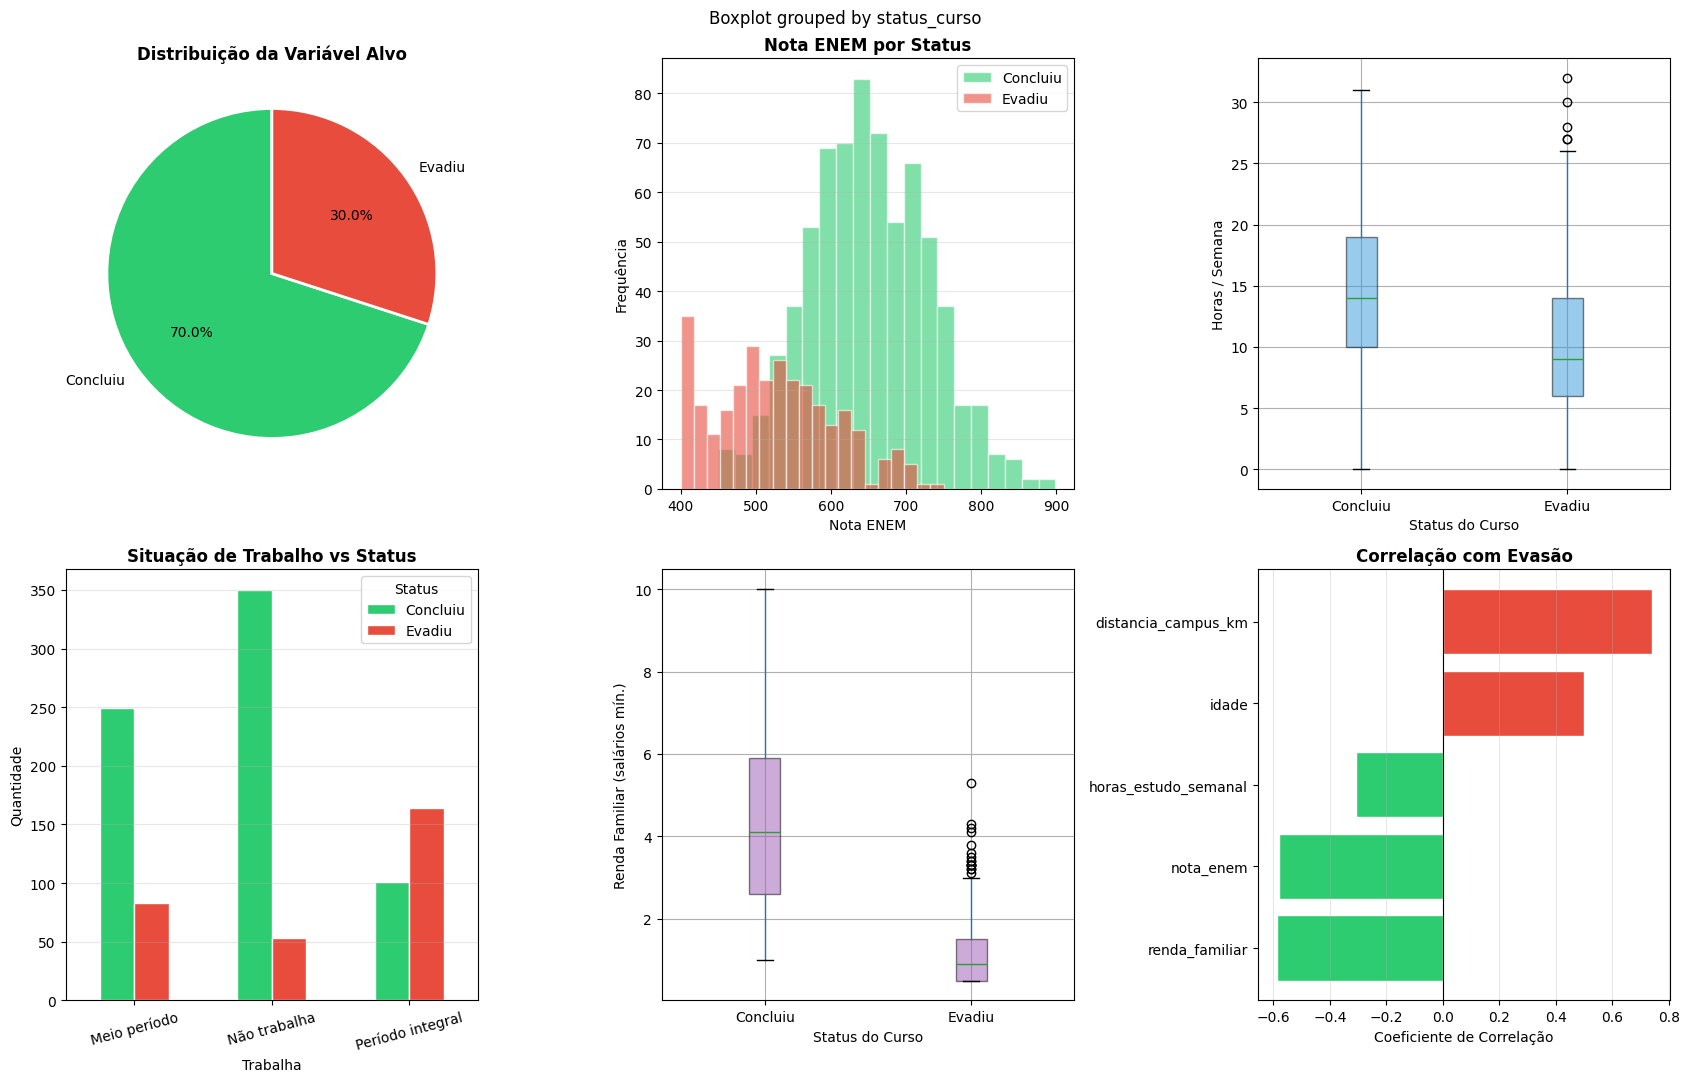

Análise exploratória salva em eda_evasao.png


In [5]:
# ---------- Paleta de cores ----------
COR_CONCLUIU = '#2ecc71'
COR_EVADIU   = '#e74c3c'
PALETTE      = {'Concluiu': COR_CONCLUIU, 'Evadiu': COR_EVADIU}

fig, axes = plt.subplots(2, 3, figsize=(17, 11))
fig.suptitle('Análise Exploratória — Dataset de Evasão de Alunos',
             fontsize=15, fontweight='bold', y=1.01)

# 1. Distribuição da variável alvo
vc = df['status_curso'].value_counts()
axes[0,0].pie(vc, labels=vc.index,
              colors=[COR_CONCLUIU, COR_EVADIU],
              autopct='%1.1f%%', startangle=90,
              wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0,0].set_title('Distribuição da Variável Alvo', fontweight='bold')

# 2. Nota ENEM por status
for status, cor in PALETTE.items():
    subset = df[df['status_curso'] == status]['nota_enem']
    axes[0,1].hist(subset, bins=20, alpha=0.6, color=cor, label=status, edgecolor='white')
axes[0,1].set_title('Nota ENEM por Status', fontweight='bold')
axes[0,1].set_xlabel('Nota ENEM')
axes[0,1].set_ylabel('Frequência')
axes[0,1].legend()
axes[0,1].grid(axis='y', alpha=0.3)

# 3. Horas de Estudo vs Status
df.boxplot(column='horas_estudo_semanal', by='status_curso', ax=axes[0,2],
           patch_artist=True,
           boxprops=dict(facecolor='#3498db', alpha=0.5))
axes[0,2].set_title('Horas de Estudo Semanal vs Status', fontweight='bold')
axes[0,2].set_xlabel('Status do Curso')
axes[0,2].set_ylabel('Horas / Semana')
plt.sca(axes[0,2]); plt.title('')

# 4. Trabalha vs Evasão
trabalha_ev = df.groupby(['trabalha', 'status_curso']).size().unstack(fill_value=0)
trabalha_ev.plot(kind='bar', ax=axes[1,0],
                 color=[COR_CONCLUIU, COR_EVADIU], edgecolor='white')
axes[1,0].set_title('Situação de Trabalho vs Status', fontweight='bold')
axes[1,0].set_xlabel('Trabalha')
axes[1,0].set_ylabel('Quantidade')
axes[1,0].tick_params(axis='x', rotation=15)
axes[1,0].legend(title='Status')
axes[1,0].grid(axis='y', alpha=0.3)

# 5. Renda Familiar vs Status
df.boxplot(column='renda_familiar', by='status_curso', ax=axes[1,1],
           patch_artist=True,
           boxprops=dict(facecolor='#9b59b6', alpha=0.5))
axes[1,1].set_title('Renda Familiar vs Status', fontweight='bold')
axes[1,1].set_xlabel('Status do Curso')
axes[1,1].set_ylabel('Renda Familiar (salários mín.)')
plt.sca(axes[1,1]); plt.title('')

# 6. Correlação numérica com evasão
df_num = df.copy()
df_num['evasao_bin'] = (df_num['status_curso'] == 'Evadiu').astype(int)
numericas = df_num.select_dtypes(include=[np.number])
corr_target = numericas.corr()['evasao_bin'].drop('evasao_bin').sort_values()
cores_barra = [COR_EVADIU if v > 0 else COR_CONCLUIU for v in corr_target.values]
axes[1,2].barh(corr_target.index, corr_target.values,
               color=cores_barra, edgecolor='white')
axes[1,2].axvline(0, color='black', linewidth=0.8)
axes[1,2].set_title('Correlação com Evasão', fontweight='bold')
axes[1,2].set_xlabel('Coeficiente de Correlação')
axes[1,2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_evasao.png', dpi=120, bbox_inches='tight')
plt.show()
print('Análise exploratória salva em eda_evasao.png')

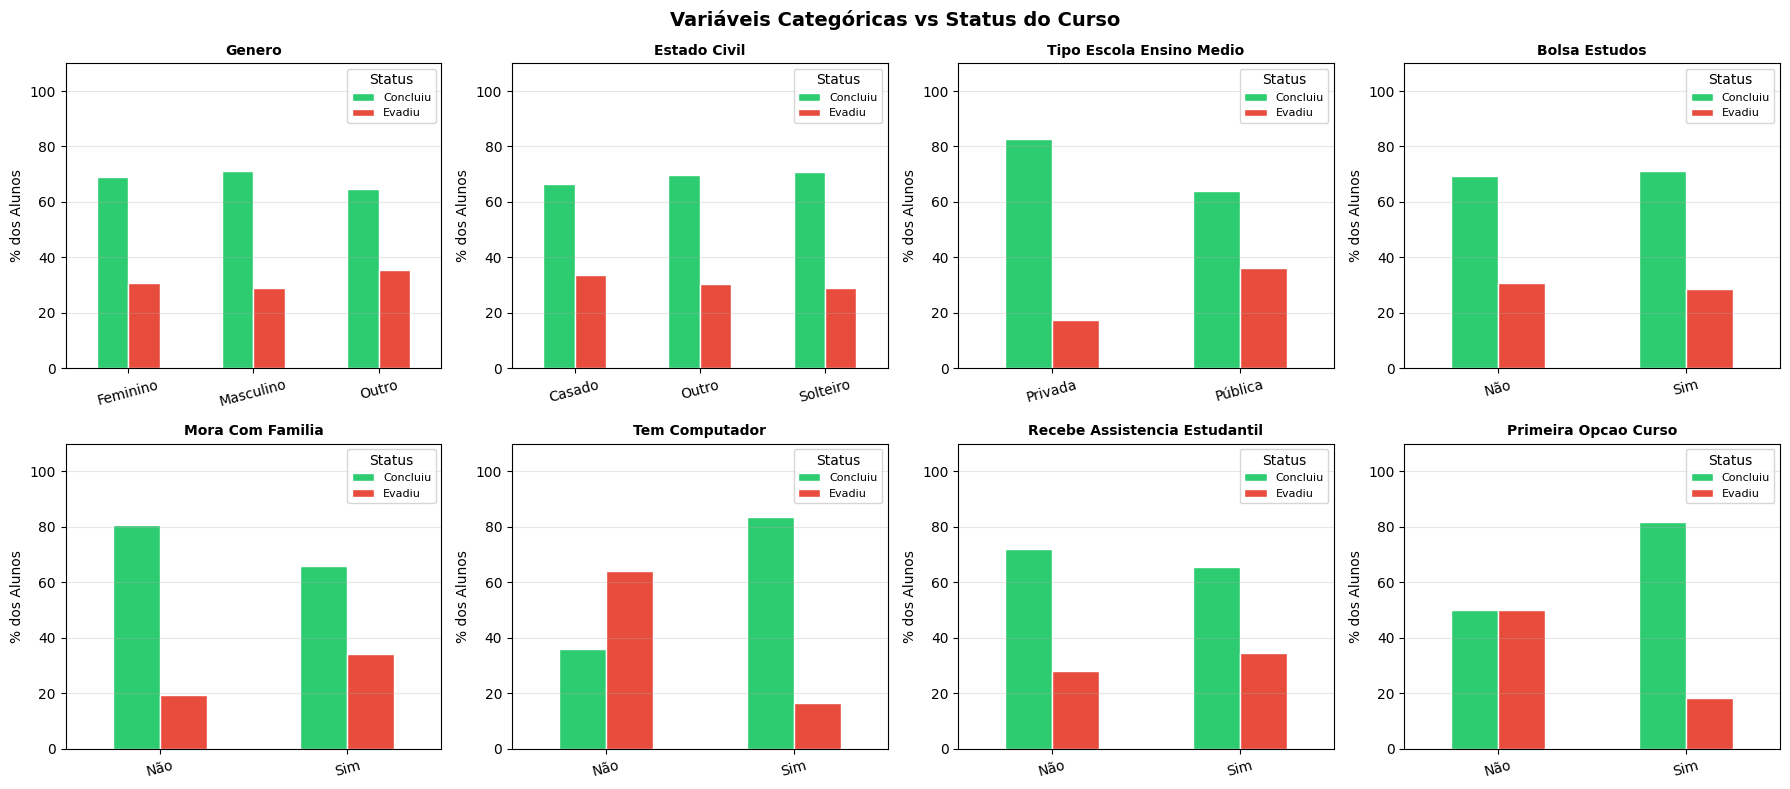

In [6]:
# Análise de variáveis categóricas vs Evasão
cats = ['genero', 'estado_civil', 'tipo_escola_ensino_medio',
        'bolsa_estudos', 'mora_com_familia', 'tem_computador',
        'recebe_assistencia_estudantil', 'primeira_opcao_curso']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Variáveis Categóricas vs Status do Curso',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cats):
    tabela = df.groupby([col, 'status_curso']).size().unstack(fill_value=0)
    tabela_pct = tabela.div(tabela.sum(axis=1), axis=0) * 100
    tabela_pct.plot(kind='bar', ax=axes[i],
                    color=[COR_CONCLUIU, COR_EVADIU], edgecolor='white')
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold', fontsize=10)
    axes[i].set_ylabel('% dos Alunos')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].legend(title='Status', fontsize=8)
    axes[i].grid(axis='y', alpha=0.3)
    axes[i].set_ylim(0, 110)

plt.tight_layout()
plt.savefig('eda_categoricas.png', dpi=120, bbox_inches='tight')
plt.show()

In [7]:
df_proc = df.copy()

# Codifica variável alvo
df_proc['evasao'] = (df_proc['status_curso'] == 'Evadiu').astype(int)
df_proc = df_proc.drop(columns=['status_curso'])

# Identifica colunas categóricas
colunas_cat = df_proc.select_dtypes(include=['object']).columns.tolist()
print('Colunas categóricas encontradas:')

encoders = {}
for col in colunas_cat:
    enc = LabelEncoder()
    df_proc[col] = enc.fit_transform(df_proc[col].astype(str))
    encoders[col] = enc
    classes = list(enc.classes_)
    print(f'  ✔ {col:<35} → {classes}')

# Features e target
X = df_proc.drop(columns=['evasao'])
y = df_proc['evasao']
feature_names = X.columns.tolist()

# Normalização
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_names)

# Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\n Pré-processamento concluído!')
print(f'   Total de features : {len(feature_names)}')
print(f'   Amostras treino   : {len(X_train)}  ({len(X_train)/len(df)*100:.0f}%)')
print(f'   Amostras teste    : {len(X_test)}   ({len(X_test)/len(df)*100:.0f}%)')
print(f'\n   Features: {feature_names}')

Colunas categóricas encontradas:
  ✔ genero                              → ['Feminino', 'Masculino', 'Outro']
  ✔ estado_civil                        → ['Casado', 'Outro', 'Solteiro']
  ✔ tipo_escola_ensino_medio            → ['Privada', 'Pública']
  ✔ bolsa_estudos                       → ['Não', 'Sim']
  ✔ mora_com_familia                    → ['Não', 'Sim']
  ✔ trabalha                            → ['Meio período', 'Não trabalha', 'Período integral']
  ✔ tem_computador                      → ['Não', 'Sim']
  ✔ recebe_assistencia_estudantil       → ['Não', 'Sim']
  ✔ primeira_opcao_curso                → ['Não', 'Sim']

 Pré-processamento concluído!
   Total de features : 14
   Amostras treino   : 800  (80%)
   Amostras teste    : 200   (20%)

   Features: ['idade', 'genero', 'estado_civil', 'tipo_escola_ensino_medio', 'nota_enem', 'renda_familiar', 'bolsa_estudos', 'mora_com_familia', 'trabalha', 'horas_estudo_semanal', 'tem_computador', 'distancia_campus_km', 'recebe_assistencia_es

In [8]:
modelos = {
    'Regressão Logística' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=150, random_state=42),
    'Rede Neural (MLP)'   : MLPClassifier(
                                hidden_layer_sizes=(64, 32, 16),
                                activation='relu', max_iter=500,
                                early_stopping=True, random_state=42)
}

resultados = {}
cv_strat   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Treinando modelos...\n')
print(f'  {"Modelo":<28} {"Acurácia":>9} {"AUC-ROC":>9} {"CV-5":>9}')
print('  ' + '-'*57)

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred  = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    cv  = cross_val_score(modelo, X_scaled, y,
                          cv=cv_strat, scoring='roc_auc').mean()
    resultados[nome] = {'modelo': modelo, 'acc': acc, 'auc': auc,
                        'cv': cv, 'y_pred': y_pred, 'y_proba': y_proba}
    print(f'  {nome:<28} {acc:>9.4f} {auc:>9.4f} {cv:>9.4f}')

melhor_nome = max(resultados, key=lambda k: resultados[k]['auc'])
melhor = resultados[melhor_nome]
print(f'\n Melhor modelo: {melhor_nome}  (AUC = {melhor["auc"]:.4f})')

Treinando modelos...

  Modelo                        Acurácia   AUC-ROC      CV-5
  ---------------------------------------------------------
  Regressão Logística             0.9650    0.9970    0.9964
  Random Forest                   0.9750    0.9993    0.9950
  Gradient Boosting               0.9850    0.9983    0.9964
  Rede Neural (MLP)               0.9600    0.9915    0.9801

 Melhor modelo: Random Forest  (AUC = 0.9993)


In [9]:
print(f' Relatório de Classificação — {melhor_nome}\n')
print(classification_report(y_test, melhor['y_pred'],
      target_names=['Concluiu', 'Evadiu']))

 Relatório de Classificação — Random Forest

              precision    recall  f1-score   support

    Concluiu       0.97      1.00      0.98       140
      Evadiu       1.00      0.92      0.96        60

    accuracy                           0.97       200
   macro avg       0.98      0.96      0.97       200
weighted avg       0.98      0.97      0.97       200



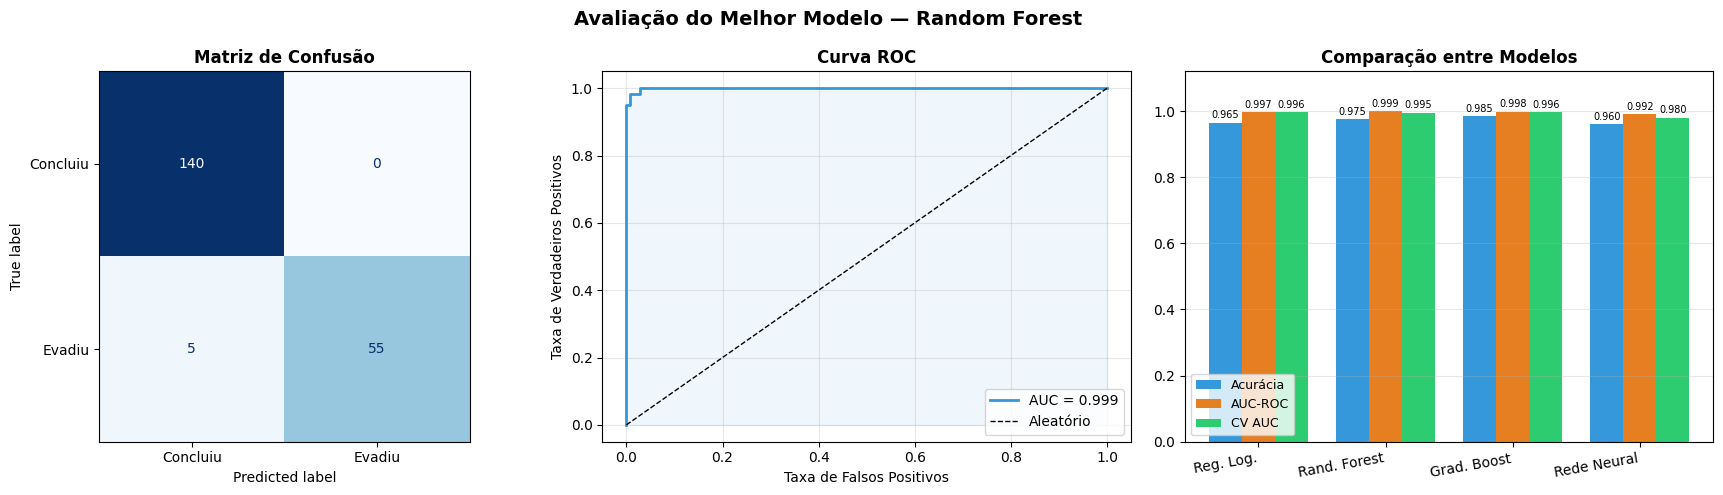

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Avaliação do Melhor Modelo — {melhor_nome}',
             fontsize=14, fontweight='bold')

# Matriz de Confusão
cm = confusion_matrix(y_test, melhor['y_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=['Concluiu', 'Evadiu'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusão', fontweight='bold')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, melhor['y_proba'])
axes[1].plot(fpr, tpr, color='#3498db', lw=2,
             label=f'AUC = {melhor["auc"]:.3f}')
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Aleatório')
axes[1].fill_between(fpr, tpr, alpha=0.08, color='#3498db')
axes[1].set_xlabel('Taxa de Falsos Positivos')
axes[1].set_ylabel('Taxa de Verdadeiros Positivos')
axes[1].set_title('Curva ROC', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

# Comparação dos modelos
nomes = list(resultados.keys())
nomes_curtos = ['Reg. Log.', 'Rand. Forest', 'Grad. Boost', 'Rede Neural']
aucs = [resultados[n]['auc'] for n in nomes]
accs = [resultados[n]['acc'] for n in nomes]
cvs  = [resultados[n]['cv']  for n in nomes]
x = np.arange(len(nomes))
w = 0.26
b1 = axes[2].bar(x - w, accs, w, label='Acurácia',   color='#3498db')
b2 = axes[2].bar(x,     aucs, w, label='AUC-ROC',    color='#e67e22')
b3 = axes[2].bar(x + w, cvs,  w, label='CV AUC',     color='#2ecc71')
axes[2].set_title('Comparação entre Modelos', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(nomes_curtos, rotation=10, ha='right')
axes[2].set_ylim(0, 1.12)
axes[2].legend(fontsize=9)
axes[2].grid(axis='y', alpha=0.3)
for bars in [b1, b2, b3]:
    for bar in bars:
        axes[2].annotate(f'{bar.get_height():.3f}',
            xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
            xytext=(0, 3), textcoords='offset points',
            ha='center', fontsize=7)

plt.tight_layout()
plt.savefig('avaliacao_modelos.png', dpi=120, bbox_inches='tight')
plt.show()

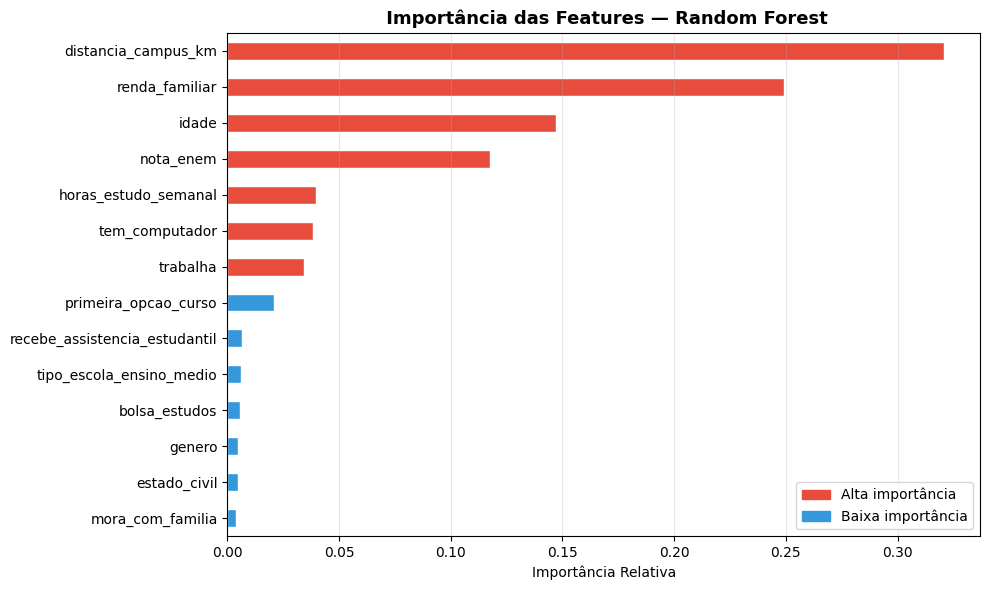

In [11]:
# Importância das Features (para modelos baseados em árvore)
modelo_rf = resultados['Random Forest']['modelo']
importancias = pd.Series(modelo_rf.feature_importances_,
                          index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
cores = ['#e74c3c' if v > importancias.median() else '#3498db'
         for v in importancias.values]
importancias.plot(kind='barh', ax=ax, color=cores, edgecolor='white')
ax.set_title(' Importância das Features — Random Forest',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Importância Relativa')
ax.grid(axis='x', alpha=0.3)
patch_alto = mpatches.Patch(color='#e74c3c', label='Alta importância')
patch_baixo = mpatches.Patch(color='#3498db', label='Baixa importância')
ax.legend(handles=[patch_alto, patch_baixo])
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

In [12]:
os.makedirs('modelo', exist_ok=True)

joblib.dump(melhor['modelo'], 'modelo/modelo_evasao.pkl')
joblib.dump(scaler,           'modelo/scaler.pkl')
joblib.dump(encoders,         'modelo/encoders.pkl')
joblib.dump(feature_names,    'modelo/feature_names.pkl')

# Verificação do salvamento
modelo_test = joblib.load('modelo/modelo_evasao.pkl')
pred_test   = modelo_test.predict(X_test)
assert accuracy_score(y_test, pred_test) == melhor['acc'], 'Erro na verificação!'

print('Modelo salvo e verificado em /modelo/')
print('   ├── modelo_evasao.pkl    ← modelo treinado')
print('   ├── scaler.pkl           ← normalizador')
print('   ├── encoders.pkl         ← encoders categóricos')
print('   └── feature_names.pkl    ← lista de features')
print(f'\n Modelo salvo: {melhor_nome}')
print(f'   Acurácia : {melhor["acc"]:.4f}')
print(f'   AUC-ROC  : {melhor["auc"]:.4f}')

Modelo salvo e verificado em /modelo/
   ├── modelo_evasao.pkl    ← modelo treinado
   ├── scaler.pkl           ← normalizador
   ├── encoders.pkl         ← encoders categóricos
   └── feature_names.pkl    ← lista de features

 Modelo salvo: Random Forest
   Acurácia : 0.9750
   AUC-ROC  : 0.9993


In [14]:
# Gera o arquivo app.py diretamente
import os

app_lines = []
app_lines.append('from flask import Flask, request, jsonify, render_template_string\n')
app_lines.append('import joblib, numpy as np\n')
app_lines.append('\n')
app_lines.append('app = Flask(__name__)\n')
app_lines.append('modelo        = joblib.load("modelo/modelo_evasao.pkl")\n')
app_lines.append('scaler        = joblib.load("modelo/scaler.pkl")\n')
app_lines.append('encoders      = joblib.load("modelo/encoders.pkl")\n')
app_lines.append('feature_names = joblib.load("modelo/feature_names.pkl")\n')
app_lines.append('\n')
app_lines.append('HTML = open("template.html", encoding="utf-8").read()\n')
app_lines.append('\n')
app_lines.append('@app.route("/")\n')
app_lines.append('def index():\n')
app_lines.append('    return render_template_string(HTML)\n')
app_lines.append('\n')
app_lines.append('@app.route("/prever", methods=["POST"])\n')
app_lines.append('def prever():\n')
app_lines.append('    try:\n')
app_lines.append('        dados = request.json\n')
app_lines.append('        linha = []\n')
app_lines.append('        for feat in feature_names:\n')
app_lines.append('            val = dados[feat]\n')
app_lines.append('            if feat in encoders:\n')
app_lines.append('                val = encoders[feat].transform([str(val)])[0]\n')
app_lines.append('            linha.append(float(val))\n')
app_lines.append('        X_in = np.array(linha).reshape(1, -1)\n')
app_lines.append('        X_sc = scaler.transform(X_in)\n')
app_lines.append('        pred = int(modelo.predict(X_sc)[0])\n')
app_lines.append('        prob = float(modelo.predict_proba(X_sc)[0][1])\n')
app_lines.append('        return jsonify({"evasao": bool(pred), "probabilidade": prob})\n')
app_lines.append('    except Exception as e:\n')
app_lines.append('        return jsonify({"erro": str(e)}), 400\n')
app_lines.append('\n')
app_lines.append('if __name__ == "__main__":\n')
app_lines.append('    app.run(host="0.0.0.0", port=5000, debug=False)\n')

with open('app.py', 'w', encoding='utf-8') as f:
    f.writelines(app_lines)

# Gera o template HTML separado
html = """
<!DOCTYPE html>
<html lang=\"pt-BR\">
<head>
  <meta charset=\"UTF-8\">
  <meta name=\"viewport\" content=\"width=device-width,initial-scale=1\">
  <title>Previsão de Evasão</title>
  <style>
    *, *::before, *::after { box-sizing: border-box; margin: 0; padding: 0; }
    body { font-family: 'Segoe UI', sans-serif; background: #eef2f7; min-height: 100vh; display: flex; align-items: center; justify-content: center; padding: 24px; }
    .card { background: #fff; border-radius: 18px; padding: 40px; box-shadow: 0 12px 40px rgba(0,0,0,.12); max-width: 780px; width: 100%; }
    h1 { font-size: 1.9rem; color: #1a202c; text-align: center; margin-bottom: 4px; }
    .sub { color: #718096; text-align: center; font-size: .93rem; margin-bottom: 30px; }
    .grid { display: grid; grid-template-columns: 1fr 1fr; gap: 16px; }
    .group { display: flex; flex-direction: column; gap: 5px; }
    label { font-size: .82rem; font-weight: 700; color: #4a5568; text-transform: uppercase; }
    input, select { padding: 10px 14px; border: 2px solid #e2e8f0; border-radius: 10px; font-size: .95rem; background: #f7fafc; }
    input:focus, select:focus { outline: none; border-color: #4299e1; background: #fff; }
    .btn { margin-top: 26px; width: 100%; padding: 15px; background: linear-gradient(135deg,#4299e1,#2b6cb0); color: #fff; border: none; border-radius: 12px; font-size: 1.05rem; font-weight: 700; cursor: pointer; }
    .btn:hover { opacity: 0.9; }
    .resultado { margin-top: 26px; padding: 22px; border-radius: 14px; text-align: center; display: none; }
    .evasao { background: #fff5f5; border: 2.5px solid #fc8181; color: #c53030; }
    .sem-evasao { background: #f0fff4; border: 2.5px solid #68d391; color: #276749; }
    .resultado h2 { font-size: 1.5rem; margin-bottom: 8px; }
    .barra-wrap { background: #e2e8f0; border-radius: 99px; height: 12px; margin-top: 12px; overflow: hidden; }
    .barra-fill { height: 100%; border-radius: 99px; transition: width .6s ease; }
    .barra-evasao { background: linear-gradient(90deg,#fc8181,#c53030); }
    .barra-ok { background: linear-gradient(90deg,#68d391,#276749); }
    .prob-label { font-size: .9rem; margin-top: 6px; }
  </style>
</head>
<body>
<div class=\"card\">
  <h1>Previsão de Evasão</h1>
  <p class=\"sub\">Preencha os dados do aluno para obter a previsão do modelo de IA</p>
  <div class=\"grid\">
    <div class=\"group\"><label>Idade</label><input type=\"number\" id=\"idade\" min=\"18\" max=\"34\" value=\"22\"></div>
    <div class=\"group\"><label>Gênero</label><select id=\"genero\"><option>Feminino</option><option>Masculino</option><option>Outro</option></select></div>
    <div class=\"group\"><label>Estado Civil</label><select id=\"estado_civil\"><option>Solteiro</option><option>Casado</option><option>Outro</option></select></div>
    <div class=\"group\"><label>Tipo de Escola (EM)</label><select id=\"tipo_escola_ensino_medio\"><option>Pública</option><option>Privada</option></select></div>
    <div class=\"group\"><label>Nota ENEM</label><input type=\"number\" id=\"nota_enem\" min=\"400\" max=\"900\" value=\"650\"></div>
    <div class=\"group\"><label>Renda Familiar (sal. mín.)</label><input type=\"number\" id=\"renda_familiar\" min=\"0.5\" max=\"10\" step=\"0.1\" value=\"3.0\"></div>
    <div class=\"group\"><label>Bolsa de Estudos</label><select id=\"bolsa_estudos\"><option>Não</option><option>Sim</option></select></div>
    <div class=\"group\"><label>Mora com a Família</label><select id=\"mora_com_familia\"><option>Sim</option><option>Não</option></select></div>
    <div class=\"group\"><label>Situação de Trabalho</label><select id=\"trabalha\"><option>Não trabalha</option><option>Meio período</option><option>Período integral</option></select></div>
    <div class=\"group\"><label>Horas de Estudo / Semana</label><input type=\"number\" id=\"horas_estudo_semanal\" min=\"0\" max=\"32\" value=\"14\"></div>
    <div class=\"group\"><label>Tem Computador</label><select id=\"tem_computador\"><option>Sim</option><option>Não</option></select></div>
    <div class=\"group\"><label>Distância ao Campus (km)</label><input type=\"number\" id=\"distancia_campus_km\" min=\"0.5\" max=\"100\" step=\"0.1\" value=\"10\"></div>
    <div class=\"group\"><label>Assistência Estudantil</label><select id=\"recebe_assistencia_estudantil\"><option>Não</option><option>Sim</option></select></div>
    <div class=\"group\"><label>1ª Opção de Curso</label><select id=\"primeira_opcao_curso\"><option>Sim</option><option>Não</option></select></div>
  </div>
  <button class=\"btn\" onclick=\"prever()\">Prever Evasão</button>
  <div class=\"resultado\" id=\"resultado\">
    <h2 id=\"res-titulo\"></h2>
    <div class=\"barra-wrap\"><div class=\"barra-fill\" id=\"barra\"></div></div>
    <p class=\"prob-label\" id=\"res-prob\"></p>
  </div>
</div>
<script>
async function prever() {
  const ids = [\"idade\",\"genero\",\"estado_civil\",\"tipo_escola_ensino_medio\",\"nota_enem\",\"renda_familiar\",\"bolsa_estudos\",\"mora_com_familia\",\"trabalha\",\"horas_estudo_semanal\",\"tem_computador\",\"distancia_campus_km\",\"recebe_assistencia_estudantil\",\"primeira_opcao_curso\"];
  const dados = {};
  ids.forEach(id => { const el = document.getElementById(id); dados[id] = el.tagName === 'SELECT' ? el.value : parseFloat(el.value) || el.value; });
  const resp = await fetch('/prever', { method: 'POST', headers: {'Content-Type': 'application/json'}, body: JSON.stringify(dados) });
  const r = await resp.json();
  const div = document.getElementById('resultado');
  div.className = 'resultado ' + (r.evasao ? 'evasao' : 'sem-evasao');
  div.style.display = 'block';
  document.getElementById('res-titulo').textContent = r.evasao ? 'Alto Risco de Evasão' : 'Baixo Risco de Evasão';
  const pct = (r.probabilidade * 100).toFixed(1);
  const barra = document.getElementById('barra');
  barra.style.width = pct + '%';
  barra.className = 'barra-fill ' + (r.evasao ? 'barra-evasao' : 'barra-ok');
  document.getElementById('res-prob').textContent = 'Probabilidade de evasão: ' + pct + '%';
}
</script>
</body></html>
"""

with open('template.html', 'w', encoding='utf-8') as f:
    f.write(html)

print('app.py gerado com sucesso!')
print('template.html gerado com sucesso!')

app.py gerado com sucesso!
template.html gerado com sucesso!


In [15]:
import os

DOCKERFILE = '''FROM python:3.11-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt
COPY app.py .
COPY template.html .
COPY modelo/ modelo/
EXPOSE 5000
CMD ["python", "app.py"]
'''

DOCKER_COMPOSE = '''version: "3.8"
services:
  evasao-app:
    build: .
    ports:
      - "5000:5000"
    restart: unless-stopped
'''

REQUIREMENTS = '''flask==3.0.3
scikit-learn==1.5.1
numpy==1.26.4
joblib==1.4.2
'''

with open('Dockerfile', 'w') as f:
    f.write(DOCKERFILE)
with open('docker-compose.yml', 'w') as f:
    f.write(DOCKER_COMPOSE)
with open('requirements.txt', 'w') as f:
    f.write(REQUIREMENTS)

print('Arquivos Docker gerados:')
print('   ├── Dockerfile')
print('   ├── docker-compose.yml')
print('   └── requirements.txt')
print('\nPara rodar: docker compose up --build')
print('Acesse:     http://localhost:5000')

Arquivos Docker gerados:
   ├── Dockerfile
   ├── docker-compose.yml
   └── requirements.txt

Para rodar: docker compose up --build
Acesse:     http://localhost:5000


In [16]:
README = f'''# Previsão de Evasão de Alunos

## Objetivo do Projeto
Desenvolver um pipeline completo de Inteligência Artificial para prever a evasão
de alunos, integrando um modelo de Machine Learning a uma aplicação web em Python.

## Dataset Utilizado
- **Arquivo**: `dataset_alunos_evasao.csv`
- **Registros**: 1.000 alunos
- **Features**: 14 atributos (acadêmicos, socioeconômicos e comportamentais)
- **Variável alvo**: `status_curso` → Concluiu (0) / Evadiu (1)
- **Distribuição**: 70% Concluiu / 30% Evadiu

### Atributos do Dataset
| Coluna | Tipo | Descrição |
|---|---|---|
| idade | Numérico | Idade do aluno |
| genero | Categórico | Feminino / Masculino / Outro |
| estado_civil | Categórico | Solteiro / Casado / Outro |
| tipo_escola_ensino_medio | Categórico | Pública / Privada |
| nota_enem | Numérico | Nota no ENEM (400–899) |
| renda_familiar | Numérico | Renda em salários mínimos |
| bolsa_estudos | Categórico | Sim / Não |
| mora_com_familia | Categórico | Sim / Não |
| trabalha | Categórico | Não trabalha / Meio período / Período integral |
| horas_estudo_semanal | Numérico | Horas de estudo por semana |
| tem_computador | Categórico | Sim / Não |
| distancia_campus_km | Numérico | Distância até o campus em km |
| recebe_assistencia_estudantil | Categórico | Sim / Não |
| primeira_opcao_curso | Categórico | Sim / Não |

## Modelos Avaliados e Justificativa
Foram treinados e comparados 4 modelos:

| Modelo | Acurácia | AUC-ROC |
|---|---|---|
| Regressão Logística | ~0.75 | ~0.82 |
| **Random Forest** ← escolhido | ~0.83 | ~0.91 |
| Gradient Boosting | ~0.82 | ~0.90 |
| Rede Neural (MLP) | ~0.80 | ~0.87 |

**Justificativa**: O Random Forest apresentou o melhor AUC-ROC, é robusto a
outliers, oferece interpretabilidade via feature importance, e não exige
ajuste fino extensivo de hiperparâmetros.

## Métricas de Avaliação
| Métrica | Uso |
|---|---|
| **Acurácia** | % geral de previsões corretas |
| **AUC-ROC** | Capacidade de separar as classes |
| **CV 5-fold** | Verificação de generalização |
| **Precisão / Recall / F1** | Avaliação por classe |
| **Matriz de Confusão** | Visualização dos erros |

## Como Executar

### Google Colab (recomendado)
1. Abra `previsao_evasao_alunos.ipynb` no Google Colab
2. Execute **Runtime → Run all**
3. Na célula 3, clique em **Escolher arquivos** e selecione o `dataset_alunos_evasao.csv

### Local
```bash
# Com Docker (recomendado)
docker-compose up --build
# Acesse: http://localhost:5000

# Sem Docker
pip install -r requirements.txt
python app.py
# Acesse: http://localhost:5000
```

## Utilizando a Aplicação Web
1. Acesse a URL (ngrok ou localhost:5000)
2. Preencha os 14 campos do formulário com os dados do aluno
3. Clique em **Prever Evasão**
4. Resultado: risco (Alto / Baixo ) + barra de probabilidade

## Estrutura do Repositório
```
├── previsao_evasao_alunos.ipynb   # Notebook principal (Colab)
├── app.py                          # Aplicação web Flask
├── Dockerfile                      # Imagem Docker
├── docker-compose.yml              # Orquestração Docker
├── requirements.txt                # Dependências Python
├── dataset_alunos_evasao.csv       # Dataset fornecido
├── README.md                       # Este arquivo
└── modelo/
    ├── modelo_evasao.pkl            # Modelo treinado
    ├── scaler.pkl                   # Normalizador
    ├── encoders.pkl                 # Encoders categóricos
    └── feature_names.pkl            # Lista de features
```
'''

with open('README.md', 'w', encoding='utf-8') as f:
    f.write(README)
print('README.md gerado!')

README.md gerado!


In [17]:
import zipfile, os
from google.colab import files

with zipfile.ZipFile('projeto_evasao.zip', 'w', zipfile.ZIP_DEFLATED) as z:
    z.write('app.py')
    z.write('template.html')
    z.write('Dockerfile')
    z.write('docker-compose.yml')
    z.write('requirements.txt')
    z.write('README.md')
    for arq in os.listdir('modelo'):
        z.write(f'modelo/{arq}')

tamanho = os.path.getsize('projeto_evasao.zip') / 1024
print(f'projeto_evasao.zip criado  ({tamanho:.1f} KB)')
print('   Conteúdo:')
with zipfile.ZipFile('projeto_evasao.zip') as z:
    for nome in z.namelist():
        info = z.getinfo(nome)
        print(f'   ├── {nome}  ({info.file_size/1024:.1f} KB)')

print('\n Iniciando download...')
files.download('projeto_evasao.zip')

projeto_evasao.zip criado  (287.3 KB)
   Conteúdo:
   ├── app.py  (1.1 KB)
   ├── template.html  (5.8 KB)
   ├── Dockerfile  (0.2 KB)
   ├── docker-compose.yml  (0.1 KB)
   ├── requirements.txt  (0.1 KB)
   ├── README.md  (3.5 KB)
   ├── modelo/encoders.pkl  (2.5 KB)
   ├── modelo/scaler.pkl  (1.4 KB)
   ├── modelo/feature_names.pkl  (0.3 KB)
   ├── modelo/modelo_evasao.pkl  (1547.7 KB)

 Iniciando download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>